# Machine Learning Lab 4 

**Name:** Sadia Fatima
**CMS:** 023-24-0213
**Section:** G
**GitHub Profile:** https://github.com/Sadia-Farooque/Machine_Learning.git
**Kaggle Profile:** https://www.kaggle.com/anamfarooque
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle


## decision tree baseline 

In [2]:
# task1
import pandas as p 

df=p.read_csv("clean_churn.csv")
print(df.shape)
df.info()
df.isnull().sum()


y = df['Churn'].map({'No': 0, 'Yes': 1})

x = df.drop(columns=['Churn'])
x = p.get_dummies(x, dtype=int)

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)





(7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null

In [3]:
# task2

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

dt = DecisionTreeClassifier(max_depth=5, random_state=42)

dt.fit(x_train, y_train)

y_test_pred = dt.predict(x_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

cm = confusion_matrix(y_test, y_test_pred)

results = p.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'Score': [accuracy, precision, recall, f1]
})

results

# The baseline Decision Tree achieves 79% accuracy,
#  but precision (0.63) is notably higher than recall
#  (0.57), meaning the model is missing about 43% of 
# actual churners (false negatives). Since correctly 
# identifying churners is more valuable than avoiding
#  false alarms in a churn use-case, this gap suggests
#  the model isn't sensitive enough at
#  catching the class we actually care about.

,Metric,Score
0,Accuracy,0.798439
1,Precision,0.634731
2,Recall,0.566845
3,F1,0.598870


In [4]:
# task3

from sklearn.ensemble import RandomForestClassifier

rf= RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

y_test_rf=rf.predict(x_test)



In [ ]:
# task 4

# A Random Forest can generalize better than
#  a single unrestricted Decision Tree because 
# it combines the predictions of many different
#  trees instead of relying on one complex tree.
# This makes the model more stable and reduces the 
# risk of overfitting to the training data.


##  Model Evaluation


Random Forest Results
Accuracy : 0.7778566359119943
Precision: 0.6033898305084746
Recall   : 0.47593582887700536
F1-score : 0.5321375186846039


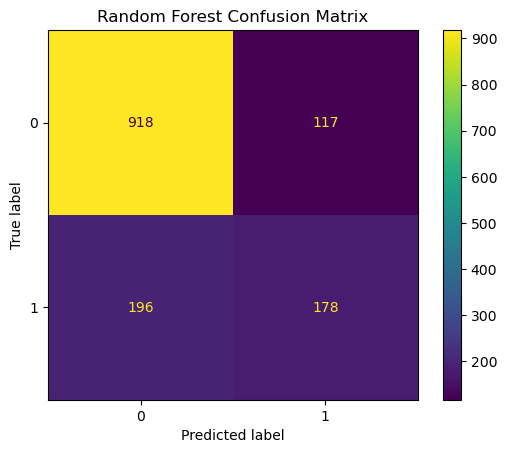

In [5]:
# task5

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accuracy_rf = accuracy_score(y_test, y_test_rf)
precision_rf = precision_score(y_test, y_test_rf)
recall_rf = recall_score(y_test, y_test_rf)
f1_rf = f1_score(y_test, y_test_rf)

print("Random Forest Results")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-score :", f1_rf)

cm_rf = confusion_matrix(y_test, y_test_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# The Random Forest gives us a better overall view than accuracy 
# alone because it shows how well the model identifies churners.
#  The confusion matrix also helps me see where the model is making 
# correct predictions and where it is confusing churners with non-churners.
#  I will pay special attention to recall and F1-score because the churn class 
# is the class I am interested in identifying.

##  Decision Tree vs Random Forest


In [6]:
# task6

comparison = p.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_rf],
    'Precision': [precision, precision_rf],
    'Recall': [recall, recall_rf],
    'F1-score': [f1, f1_rf]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.798439,0.634731,0.566845,0.598870
1,Random Forest,0.777857,0.603390,0.475936,0.532138


This table makes the comparison easier because both models are being judged using the same four metrics and the same test set. The model I prefer is not decided by accuracy alone. Since churn is the positive class and the dataset has class imbalance, recall and F1-score are especially important because they show how well the model finds actual churners while keeping the overall prediction balanced.

## Cross-Validation


In [7]:
# task8

from sklearn.model_selection import cross_val_score

dt_cv_scores = cross_val_score(dt, x, y, cv=5, scoring='f1')
rf_cv_scores = cross_val_score(rf, x, y, cv=5, scoring='f1')

print("Decision Tree F1 scores:", dt_cv_scores)
print("Decision Tree mean F1:", dt_cv_scores.mean())
print("Decision Tree std:", dt_cv_scores.std())

print("\nRandom Forest F1 scores:", rf_cv_scores)
print("Random Forest mean F1:", rf_cv_scores.mean())
print("Random Forest std:", rf_cv_scores.std())

Decision Tree F1 scores: [0.61246612 0.62382865 0.59259259 0.5907781  0.57720058]
Decision Tree mean F1: 0.5993732080724318
Decision Tree std: 0.016619092795368173

Random Forest F1 scores: [0.56221198 0.54901961 0.5015015  0.55161787 0.56410256]
Random Forest mean F1: 0.5456907057331591
Random Forest std: 0.022851029575086286


Cross-validation gives a more reliable picture than depending on one train/test split. Here, the model is tested across five different folds, so I can see whether its F1-score stays reasonably consistent. A higher mean F1 is better, while a smaller standard deviation means the performance is more stable between folds.

Compared with the single test split, the cross-validation results give me more confidence in the comparison because the models are evaluated on multiple splits. If the same model stays ahead in mean F1, I would consider that stronger evidence than the result from only one split. Small differences should still be treated carefully because model performance can change between different samples.

## Hyperparameter Tuning


In [8]:
# task10

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1:", grid_search.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validated F1: 0.5723065203585923


I used a small grid instead of trying a very large number of combinations. The three parameters are related to the size and complexity of the forest: the number of trees, the maximum depth of each tree, and the minimum number of samples needed to split a node. GridSearchCV tests these combinations using cross-validation, so the selected settings are based on more than one split.

In [9]:
# task11

best_rf = grid_search.best_estimator_

print("Best hyperparameters:")
print(grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

Best hyperparameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-score: 0.5723065203585923


In [10]:
# task12

y_test_tuned = best_rf.predict(x_test)

accuracy_tuned = accuracy_score(y_test, y_test_tuned)
precision_tuned = precision_score(y_test, y_test_tuned)
recall_tuned = recall_score(y_test, y_test_tuned)
f1_tuned = f1_score(y_test, y_test_tuned)

print("Tuned Random Forest Results")
print("Accuracy :", accuracy_tuned)
print("Precision:", precision_tuned)
print("Recall   :", recall_tuned)
print("F1-score :", f1_tuned)

Tuned Random Forest Results
Accuracy : 0.8005677785663591
Precision: 0.658703071672355
Recall   : 0.516042780748663
F1-score : 0.5787106446776612


The tuned Random Forest is evaluated on the held-out test set, which was not used to choose the hyperparameters. This is important because otherwise the reported test performance could be overly optimistic. I compare all four metrics with the default Random Forest to see whether tuning actually produced a meaningful improvement rather than assuming that more tuning is automatically better.

##  Final Model Comparison


In [11]:
# task13

final_comparison = p.DataFrame({
    'Model': ['Decision Tree', 'Default Random Forest', 'Tuned Random Forest'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_tuned],
    'Precision': [precision, precision_rf, precision_tuned],
    'Recall': [recall, recall_rf, recall_tuned],
    'F1-score': [f1, f1_rf, f1_tuned]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.798439,0.634731,0.566845,0.598870
1,Default Random Forest,0.777857,0.603390,0.475936,0.532138
2,Tuned Random Forest,0.800568,0.658703,0.516043,0.578711


This final table puts all three models in one place. I am comparing the test-set results using accuracy, precision, recall, and F1-score instead of selecting a model from only one number. The tuned model should only be considered a real improvement if its test-set performance is better in the metrics that matter for churn, especially recall and F1-score.

## Feature Importance


Top 5 important features:
tenure                     0.147687
TotalCharges               0.121887
Contract_Month-to-month    0.097549
MonthlyCharges             0.083842
OnlineSecurity_No          0.057482
dtype: float64


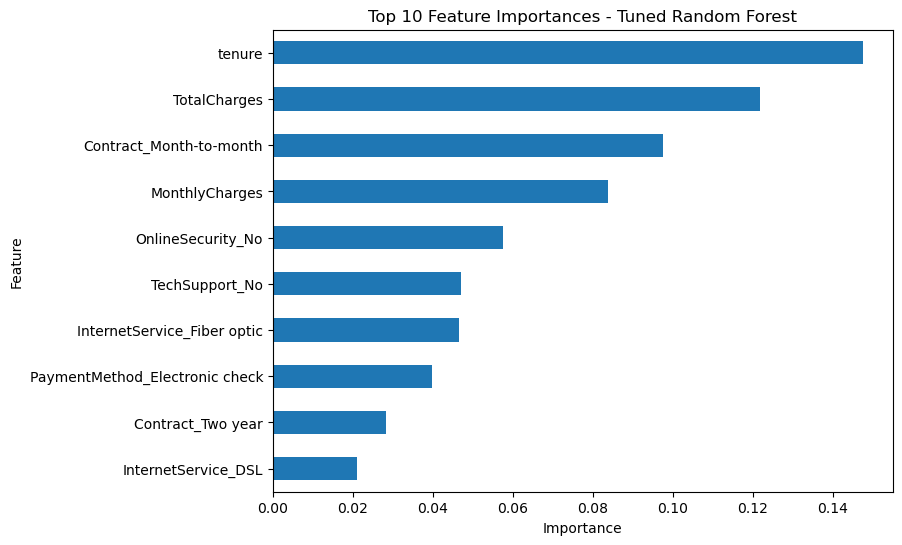

In [12]:
# task15

importances = best_rf.feature_importances_

feature_importance = p.Series(
    importances,
    index=x.columns
).sort_values(ascending=False)

print("Top 5 important features:")
print(feature_importance.head(5))

plt.figure(figsize=(8, 6))
feature_importance.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Feature importance shows which input features the Random Forest relied on most when making its predictions. The top features are useful for understanding what patterns the model is picking up from the dataset. These results should be compared with the EDA and Decision Tree findings from the earlier labs rather than treated as proof that one feature directly causes churn.

##  Final Model Selection


In [13]:
# task14

best_f1_model = final_comparison.loc[
    final_comparison['F1-score'].idxmax()
]

print("Model with the highest test F1-score:")
print(best_f1_model)

Model with the highest test F1-score:
Model        Decision Tree
Accuracy          0.798439
Precision         0.634731
Recall            0.566845
F1-score           0.59887
Name: 0, dtype: object


I selected the final model by looking at the held-out test results, with F1-score as the main metric because the dataset has class imbalance and I want a balance between finding churners and avoiding too many incorrect positive predictions. I also checked precision, recall, and accuracy instead of relying only on the highest training score. This makes the final choice more evidence-based and closer to how a model would be evaluated in a real situation.

##  Kaggle Prediction/Submission


In [14]:
# task16

final_model = best_f1_model['Model']

if final_model == 'Decision Tree':
    final_predictions = y_test_pred
elif final_model == 'Default Random Forest':
    final_predictions = y_test_rf
else:
    final_predictions = y_test_tuned

# Use the original customer identifier if it is available.
# If it is not available in the cleaned dataset, use the test-set index.
if 'customerID' in df.columns:
    customer_id = df.loc[x_test.index, 'customerID'].values
else:
    customer_id = x_test.index

submission = p.DataFrame({
    'customerID': customer_id,
    'Churn': ['Yes' if value == 1 else 'No' for value in final_predictions]
})

submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully")
submission.head()

submission.csv created successfully


,customerID,Churn
0,437,No
1,2280,Yes
2,2235,No
3,4460,Yes
4,3761,No


The submission dataframe contains the customer identifier and the predicted Churn value, following the structure requested in the lab. I saved it as submission.csv. This is similar to a Kaggle-style workflow where a trained model produces predictions in a separate file for submission.

## Conclusion


In this lab, I compared a Decision Tree with a default Random Forest and then tuned the Random Forest using GridSearchCV. The Random Forest approach is useful because it combines many trees and can be more stable than relying on one tree. I used accuracy, precision, recall, F1-score and cross-validation instead of judging the models by accuracy alone. The final model was selected using the held-out test results, with F1-score given extra importance because the churn classes are imbalanced. One limitation is that the model can still miss some customers who actually churn, so its predictions should not be treated as perfect. If I had more time, I would try other algorithms, more careful tuning, and techniques that directly handle class imbalance, as suggested in the lab.